# LeetCode #163: Missing Ranges

https://leetcode.com/problems/missing-ranges/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Linear Scan** | $O(n)$ | $O(1)$ extra |

---

## Understanding the Methods

### Linear Scan ★
Walk through the sorted array while tracking the next expected value (starting from `lower`). For each element:
1. If the current element is greater than `next`, there is a gap — add the range `[next, nums[i] - 1]` to the result.
2. Update `next = nums[i] + 1`.

After the loop, if `next <= upper`, add the final range `[next, upper]`.

**Why this works:** The array is sorted and contains unique values. Any gap between consecutive elements (or between `lower`/`upper` and the array boundaries) represents a missing range.

**Constraints:**
* `-10^9 <= lower <= upper <= 10^9`
* All values in `nums` are within `[lower, upper]` and unique.
* The updated version returns `List<List<int>>` with `[start, end]` pairs.

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<IList<int>> FindMissingRanges(int[] nums, int lower, int upper) {
        var result = new List<IList<int>>();
        long next = lower;
        
        foreach (int num in nums) {
            if (num > next) {
                result.Add(new List<int> { (int)next, num - 1 });
            }
            next = (long)num + 1;
        }
        
        if (next <= upper) {
            result.Add(new List<int> { (int)next, upper });
        }
        
        return result;
    }
}

### Python

In [ ]:
class Solution:
    def findMissingRanges(self, nums: list[int], lower: int, upper: int) -> list[list[int]]:
        result = []
        nxt = lower
        
        for num in nums:
            if num > nxt:
                result.append([nxt, num - 1])
            nxt = num + 1
        
        if nxt <= upper:
            result.append([nxt, upper])
        
        return result

### Go

In [ ]:
func findMissingRanges(nums []int, lower int, upper int) [][]int {
    result := [][]int{}
    next := lower
    
    for _, num := range nums {
        if num > next {
            result = append(result, []int{next, num - 1})
        }
        next = num + 1
    }
    
    if next <= upper {
        result = append(result, []int{next, upper})
    }
    
    return result
}

### Rust

In [ ]:
impl Solution {
    pub fn find_missing_ranges(nums: Vec<i32>, lower: i32, upper: i32) -> Vec<Vec<i32>> {
        let mut result = Vec::new();
        let mut next = lower as i64;
        
        for &num in &nums {
            if (num as i64) > next {
                result.push(vec![next as i32, num - 1]);
            }
            next = num as i64 + 1;
        }
        
        if next <= upper as i64 {
            result.push(vec![next as i32, upper]);
        }
        
        result
    }
}

## Example Scenarios

1. **Common Case:** `nums = [0,1,3,50,75]`, `lower = 0`, `upper = 99` $\Rightarrow$ `[[2,2],[4,49],[51,74],[76,99]]`. Walk through nums tracking `next` expected value. Gaps at 2, 4-49, 51-74, and 76-99. Four missing ranges of varying sizes. $O(n) = O(5)$ iterations.

2. **Slightly Complex:** `nums = [3,5,8,12]`, `lower = 1`, `upper = 15` $\Rightarrow$ `[[1,2],[4,4],[6,7],[9,11],[13,15]]`. Gaps at start, between every pair, and at end. Both single-element ranges (like $[4,4]$) and multi-element ranges appear. WHY tricky: the lower bound itself is missing, creating a gap before the first element.

3. **Edge Case (Time):** `nums = [0,1,2,...,99999]` (all $10^5$ values), `lower = 0`, `upper = 99999` $\Rightarrow$ `[]`. No gaps. The algorithm scans every element: `next` always equals the current number. After the loop, `next = 100000 > upper`. $O(10^5)$ iterations with zero output. WHY tricky: maximum input size; must scan everything to confirm nothing is missing.

4. **Edge Case (Space):** `nums = []`, `lower = -10^9`, `upper = 10^9` $\Rightarrow$ `[[-10^9, 10^9]]`. Empty array — the entire range is one gap covering $2 \times 10^9 + 1$ values. WHY tricky: uses `long`/`i64` to avoid overflow when computing `num + 1` near $\pm 10^9$. Minimal output despite enormous represented range.

5. **Almost-Impossible but Plausible:** `nums = [-10^9, 10^9]`, `lower = -10^9`, `upper = 10^9` $\Rightarrow$ `[[-999999999, 999999999]]`. Two elements at extreme bounds with a single gap of $2 \times 10^9 - 1$ values between them. Computing `next = -10^9 + 1` is fine, but `next = 10^9 + 1$ exceeds the gap check. WHY tricky: overflow-adjacent at the upper bound; $10^9 + 1 < 2^{31}-1$ so 32-bit is safe here, but dangerously close.

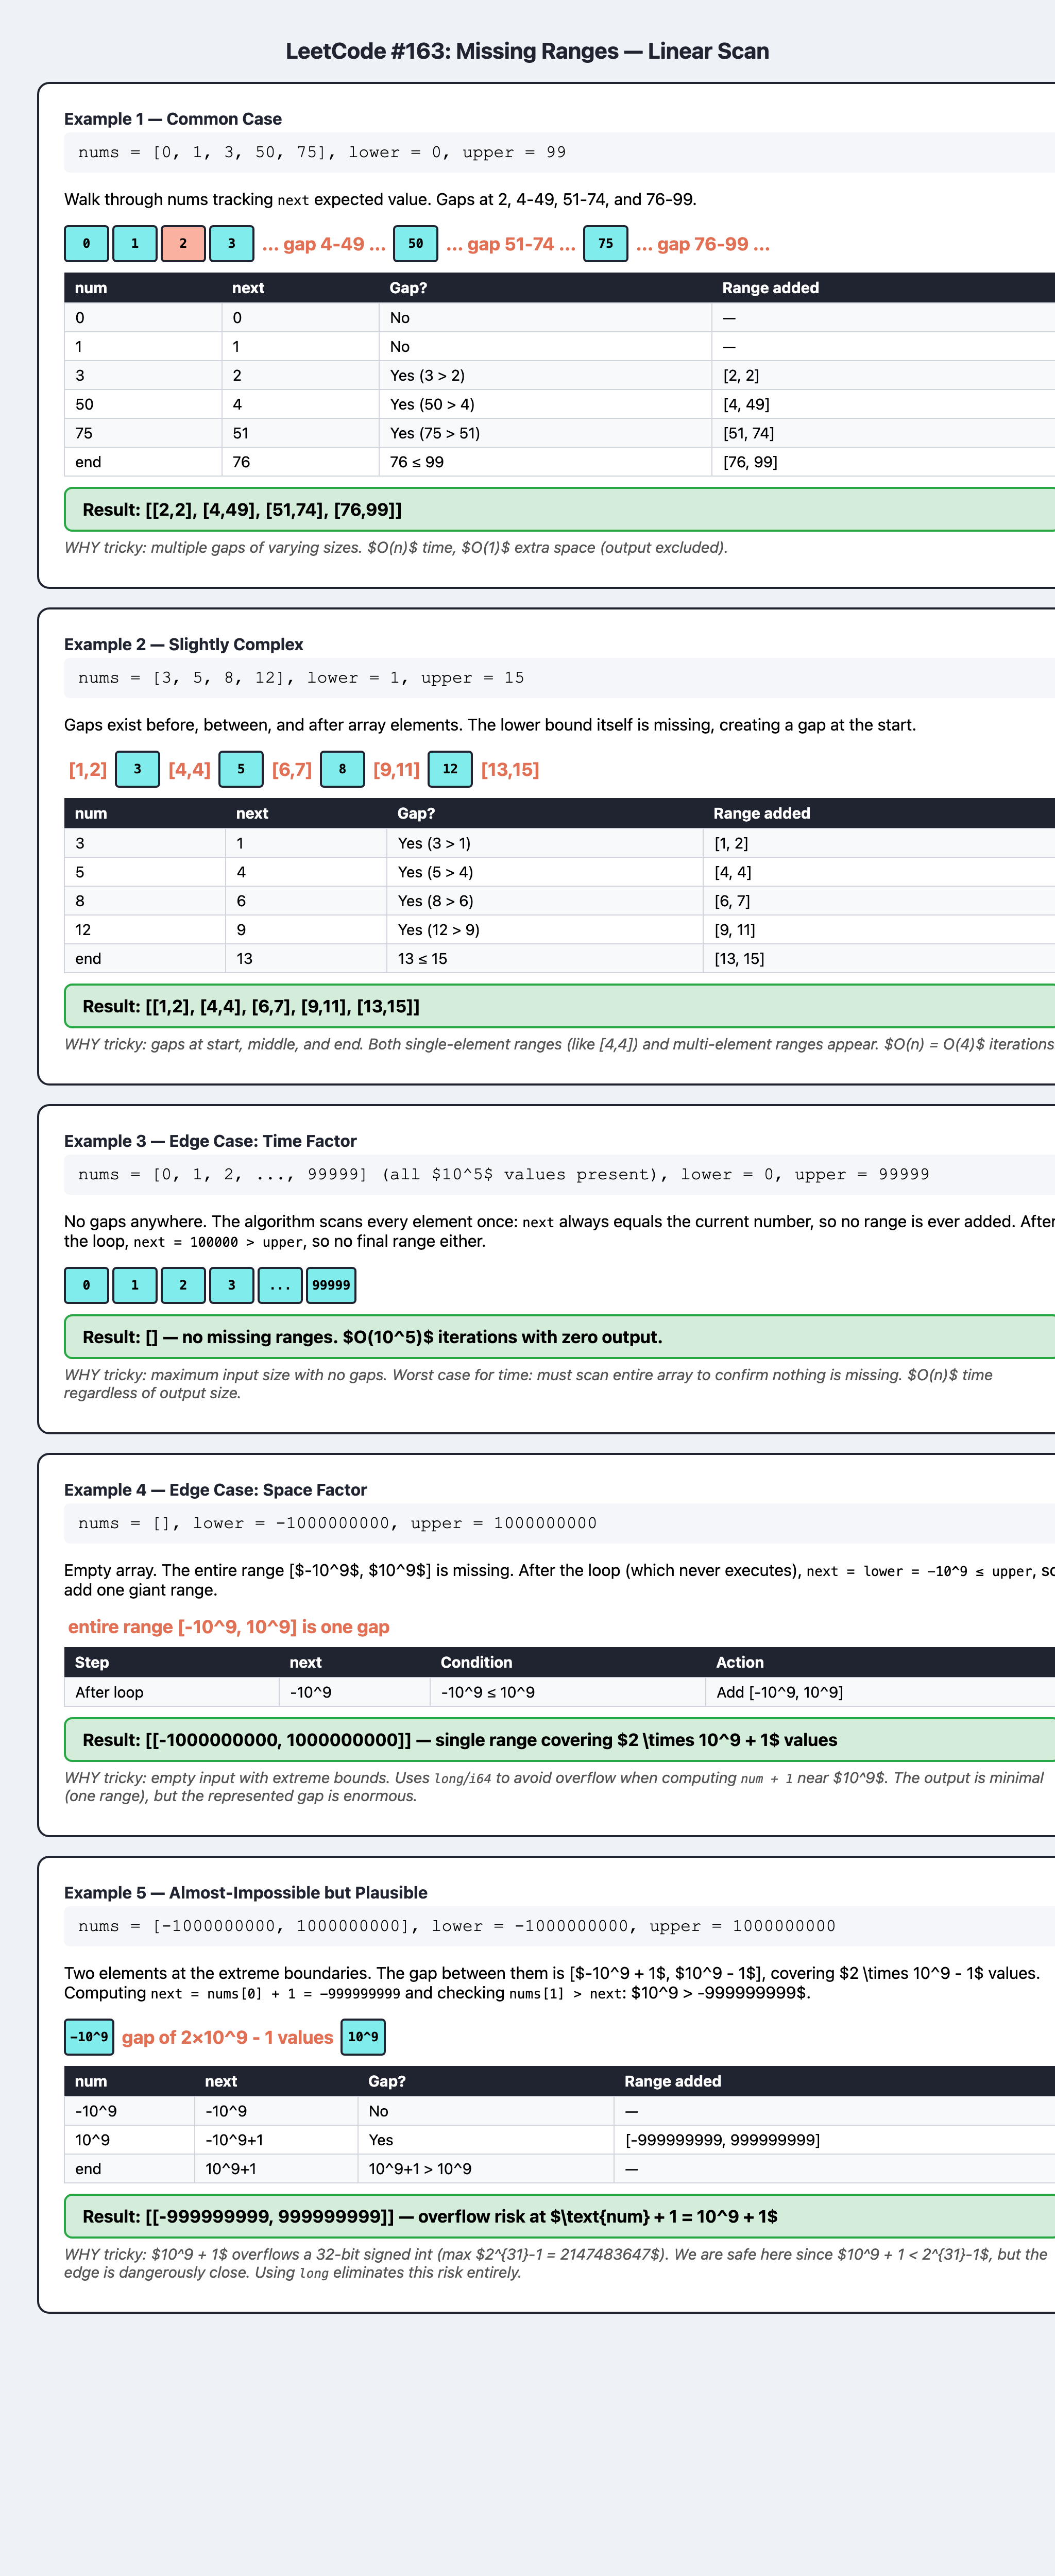